In [ ]:
# !pip install pandas
# !pip install matplotlib

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("sample_emails.csv")
df.head()

,sender,subject,links,attachment,urgent_words,status
0,security-update@paypaI.com,Reset Password,http://fake-login.com,yes,yes,suspicious
1,hr@company.com,Meeting Reminder,no,no,no,safe
2,support@amaz0n.com,Account Verification,http://secure-amazon-login.net,yes,yes,suspicious
3,admin@bankofamerica.co,Security Alert,http://boa-update.com,no,yes,suspicious
4,it@google-support.org,Email Update Required,http://gmail-fix.org,yes,no,suspicious


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sender        17 non-null     str  
 1   subject       17 non-null     str  
 2   links         17 non-null     str  
 3   attachment    17 non-null     str  
 4   urgent_words  17 non-null     str  
 5   status        17 non-null     str  
dtypes: str(6)
memory usage: 948.0 bytes


In [7]:
df.isnull().sum()

sender          0
subject         0
links           0
attachment      0
urgent_words    0
status          0
dtype: int64

In [8]:
df["status"].value_counts()

status
suspicious    11
safe           6
Name: count, dtype: int64

In [9]:
df["suspicious_domain"] = df["sender"].str.contains("paypaI|micros0ft|arnazon", case=False)

In [10]:
df["has_urgent_language"] = df["urgent_words"] == "yes"

In [11]:
df["has_attachment"] = df["attachment"] == "yes"

In [12]:
df["risk_score"] = (
    df["suspicious_domain"].astype(int) * 2 +
    df["has_urgent_language"].astype(int) +
    df["has_attachment"].astype(int)
)

In [13]:
def classify_risk(score):
    if score >= 3:
        return "high"
    elif score >= 2:
        return "medium"
    else:
        return "low"

df["risk_level"] = df["risk_score"].apply(classify_risk)

In [16]:
high_risk = df[df["risk_level"] == "high"]
print(high_risk[["sender", "subject", "risk_score"]])

                       sender         subject  risk_score
0  security-update@paypaI.com  Reset Password           4


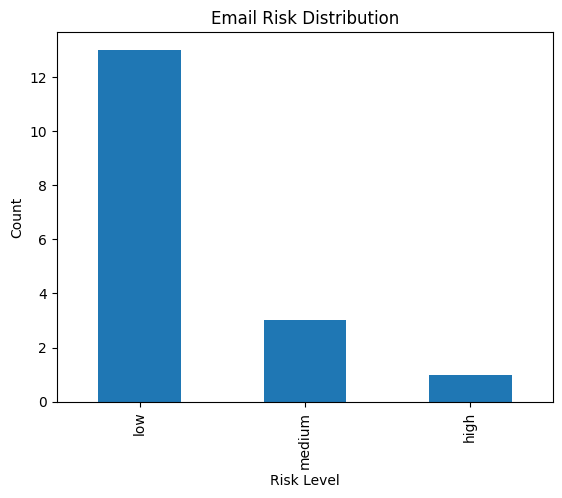

In [15]:
df["risk_level"].value_counts().plot(kind="bar")
plt.title("Email Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()